# RNN Example for Time Series

-----
------
## Data

Release: Advance Monthly Sales for Retail and Food Services
Units: Millions of Dollars, Not Seasonally Adjusted

Frequency: Monthly

The value for the most recent month is an advance estimate that is based on data from a subsample of firms from the larger Monthly Retail Trade Survey. The advance estimate will be superseded in following months by revised estimates derived from the larger Monthly Retail Trade Survey. The associated series from the Monthly Retail Trade Survey is available at https://fred.stlouisfed.org/series/MRTSSM448USN

Information about the Advance Monthly Retail Sales Survey can be found on the Census website at https://www.census.gov/retail/marts/about_the_surveys.html

Suggested Citation: U.S. Census Bureau, Advance Retail Sales: Clothing and Clothing Accessory Stores [RSCCASN], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/RSCCASN, November 16, 2019.

https://fred.stlouisfed.org/series/RSCCASN

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\Data\data tensorflow\RSCCASN.csv', index_col='DATE', parse_dates = True)

In [3]:
df.head()

,RSCCASN
DATE,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558


In [4]:
df.columns=['Sale']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 334 entries, 1992-01-01 to 2019-10-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Sale    334 non-null    int64
dtypes: int64(1)
memory usage: 5.2 KB


In [6]:
df.head()

,Sale
DATE,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558


In [7]:
plt.style.use(['science','notebook','grid'])

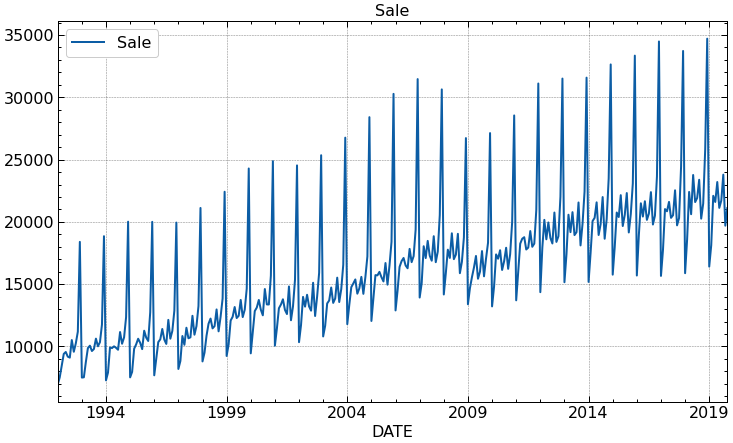

In [8]:
df.plot(figsize=(12, 7), title='Sale');

## Train test split

- menganalisa 1.5 tahun atau 18 bulan 

In [9]:
len(df)

334

In [10]:
test_point = 18 # 1.5 tahun

In [11]:
len(df)-18

316

In [12]:
test_index = len(df) - 18

In [13]:
train = df.iloc[:test_index]
test = df.iloc[test_index:]

In [14]:
train

,Sale
DATE,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558
...,...
2017-12-01,33720
2018-01-01,15881
2018-02-01,18585


In [15]:
test

,Sale
DATE,
2018-05-01,23764
2018-06-01,21589
2018-07-01,21919
2018-08-01,23381
2018-09-01,20260
2018-10-01,21473
2018-11-01,25831
2018-12-01,34706
2019-01-01,16410


----
----
## Scaler data

In [16]:
from sklearn.preprocessing import MinMaxScaler

In [17]:
scaler = MinMaxScaler()

In [18]:
scaler_train = scaler.fit_transform(train)

In [19]:
scaler_test = scaler.transform(test)

----
----
## Timeseries Generator

In [20]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [21]:
help(TimeseriesGenerator)

Help on class TimeseriesGenerator in module keras.preprocessing.sequence:

class TimeseriesGenerator(keras.utils.data_utils.Sequence)
 |  TimeseriesGenerator(data, targets, length, sampling_rate=1, stride=1, start_index=0, end_index=None, shuffle=False, reverse=False, batch_size=128)
 |  
 |  Utility class for generating batches of temporal data.
 |  
 |  Deprecated: `tf.keras.preprocessing.sequence.TimeseriesGenerator` does not
 |  operate on tensors and is not recommended for new code. Prefer using a
 |  `tf.data.Dataset` which provides a more efficient and flexible mechanism for
 |  batching, shuffling, and windowing input. See the
 |  [tf.data guide](https://www.tensorflow.org/guide/data) for more details.
 |  
 |  This class takes in a sequence of data-points gathered at
 |  equal intervals, along with time series parameters such as
 |  stride, length of history, etc., to produce batches for
 |  training/validation.
 |  
 |  Arguments:
 |      data: Indexable generator (such as li

In [22]:
length = 12 
generator = TimeseriesGenerator(scaler_train, scaler_train, length=length, batch_size= 1)

In [23]:
# genrator pertama
X,y = generator[0]

In [24]:
print(f'Given the array : {X.flatten()} \n')
print(f'Prediction y : {y}')

Given the array : [0.         0.02127505 0.05580163 0.08942056 0.09512053 0.08146965
 0.07860151 0.12979233 0.09566512 0.1203892  0.15426227 0.41595266] 

Prediction y : [[0.02047633]]


---
---
## Create Model

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [26]:
n_features = 1

In [27]:
model =Sequential()

# lstm layers
model.add(LSTM(100, input_shape=(length, n_features), activation='relu'))

# output layers
model.add(Dense(1))

# compile model
model.compile(loss='mse', optimizer='adam')

In [28]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 100)               40800     
                                                                 
 dense (Dense)               (None, 1)                 101       
                                                                 
Total params: 40,901
Trainable params: 40,901
Non-trainable params: 0
_________________________________________________________________


## Add Earlystopping ad Validation Generator

In [29]:
from tensorflow.keras.callbacks import EarlyStopping

In [30]:
early_stop  = EarlyStopping(monitor='val_loss', patience=2)

In [31]:
# validation generator
validation_generator = TimeseriesGenerator(scaler_test, scaler_test, length=length, batch_size=1)

-------
------
# fitting  Model

In [32]:
model.fit(generator, epochs =20, 
          validation_data= validation_generator, 
          callbacks =[early_stop])

Epoch 1/20
304/304 [==============================] - 12s 21ms/step - loss: 0.0231 - val_loss: 0.0128
Epoch 2/20
304/304 [==============================] - 6s 18ms/step - loss: 0.0176 - val_loss: 0.0018
Epoch 3/20
304/304 [==============================] - 6s 18ms/step - loss: 0.0104 - val_loss: 0.0011
Epoch 4/20
304/304 [==============================] - 7s 21ms/step - loss: 0.0051 - val_loss: 4.2228e-04
Epoch 5/20
304/304 [==============================] - 8s 25ms/step - loss: 0.0043 - val_loss: 0.0033
Epoch 6/20
304/304 [==============================] - 9s 29ms/step - loss: 0.0022 - val_loss: 0.0025


In [33]:
losses = pd.DataFrame(model.history.history)

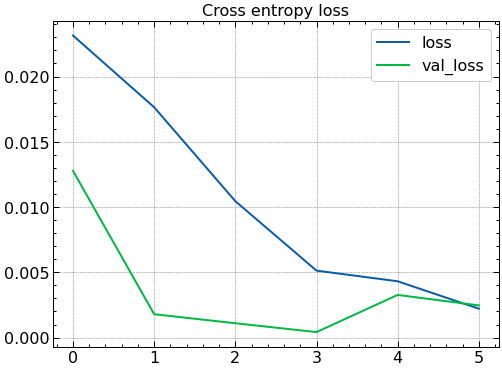

In [34]:
losses.plot(title='Cross entropy loss');

---
## Evaluation on test data

In [35]:
test_predictions = []
first_evaluation_batch = scaler_train[-length:]
current_batch = first_evaluation_batch.reshape((1, length, n_features))

for i in range(len(test)):
    # predict current 
    current_pred = model.predict(current_batch)[0]
    
    # store predict
    test_predictions.append(current_pred)
    
    # update batch | prediction | drop first values
    current_batch = np.append(current_batch[:,1:,:], [[current_pred]], axis =1)

1/1 [==============================] - 0s 110ms/step


---
---
## Inverse transform and compire

In [36]:
true_predictions = scaler.inverse_transform(test_predictions)

In [37]:
true_predictions

array([[22328.8150835 ],
       [21123.68332434],
       [21436.52870131],
       [23402.0519042 ],
       [20740.12447691],
       [21533.5840559 ],
       [25932.96765471],
       [38237.72388744],
       [16447.62539196],
       [19236.26064754],
       [23076.20222282],
       [21421.60847425],
       [23257.67145443],
       [22120.99083376],
       [22561.19335127],
       [24597.05242205],
       [22009.4322567 ],
       [23077.66994762]])

In [38]:
test['Prediction'] = true_predictions

C:\Users\ibrahim\AppData\Local\Temp\ipykernel_9384\168099314.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Prediction'] = true_predictions


In [39]:
test

,Sale,Prediction
DATE,,
2018-05-01,23764,22328.815084
2018-06-01,21589,21123.683324
2018-07-01,21919,21436.528701
2018-08-01,23381,23402.051904
2018-09-01,20260,20740.124477
2018-10-01,21473,21533.584056
2018-11-01,25831,25932.967655
2018-12-01,34706,38237.723887
2019-01-01,16410,16447.625392


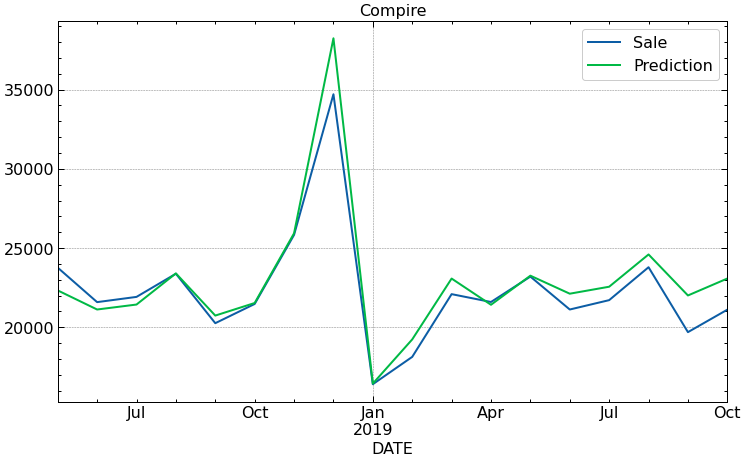

In [40]:
test.plot(figsize=(12, 7), title='Compire');

## Retrain and forecase

In [41]:
# scaler data
scaler_data = MinMaxScaler()

In [42]:
full_data_scaler = scaler_data.fit_transform(df)

In [43]:
length = 12
generator = TimeseriesGenerator(full_data_scaler, full_data_scaler, length=length, batch_size =1)

In [44]:
# model
model = Sequential()
model.add(LSTM(100, input_shape=(length, n_features), activation='relu'))
model.add(Dense(1))
model.compile(loss='mse', optimizer='adam')

In [45]:
model.fit(generator, epochs=8, verbose=1)

Epoch 1/8
322/322 [==============================] - 14s 19ms/step - loss: 0.0236
Epoch 2/8
322/322 [==============================] - 7s 21ms/step - loss: 0.0194
Epoch 3/8
322/322 [==============================] - 7s 22ms/step - loss: 0.0146
Epoch 4/8
322/322 [==============================] - 7s 21ms/step - loss: 0.0085
Epoch 5/8
322/322 [==============================] - 7s 22ms/step - loss: 0.0035
Epoch 6/8
322/322 [==============================] - 7s 20ms/step - loss: 0.0020
Epoch 7/8
322/322 [==============================] - 7s 22ms/step - loss: 0.0015
Epoch 8/8
322/322 [==============================] - 6s 19ms/step - loss: 0.0017


In [46]:
forecase = []
periods = 12

first_evaluation_batch = scaler_train[-length:]
current_batch = first_evaluation_batch.reshape((1, length, n_features))

for i in range(periods):
    # predict current
    current_pred = model.predict(current_batch)[0]
    
    # store predict
    forecase.append(current_pred)
    
    # update batc | prediction | drop first values
    current_batch = np.append(current_batch[:,1:,:], [[current_pred]], axis=1)

1/1 [==============================] - 0s 87ms/step


In [47]:
forecase = scaler.inverse_transform(forecase)

In [48]:
forecase 

array([[22209.06745577],
       [21117.45780706],
       [21375.99736643],
       [23305.98652506],
       [20693.29026508],
       [21306.55625248],
       [25565.46348381],
       [36570.89745712],
       [16639.44011331],
       [19140.12713575],
       [22714.99252272],
       [21240.72042227]])

----
----
## Create new timestamp index

In [49]:
df

,Sale
DATE,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558
...,...
2019-06-01,21123
2019-07-01,21714
2019-08-01,23791


In [50]:
df.tail()

,Sale
DATE,
2019-06-01,21123
2019-07-01,21714
2019-08-01,23791
2019-09-01,19695
2019-10-01,21113


## Pandas frequency string
https://stackoverflow.com/questions/35339139/where-is-the-documentation-on-pandas-freq-tags

https://pandas.pydata.org/docs/user_guide/timeseries.html

**``MS``**       month start frequency


In [51]:
forcase_index = pd.date_range(start='2019-11-01', periods=periods, freq='MS')

In [52]:
forcase_index

DatetimeIndex(['2019-11-01', '2019-12-01', '2020-01-01', '2020-02-01',
               '2020-03-01', '2020-04-01', '2020-05-01', '2020-06-01',
               '2020-07-01', '2020-08-01', '2020-09-01', '2020-10-01'],
              dtype='datetime64[ns]', freq='MS')

In [53]:
forecase_df = pd.DataFrame(data=forecase, index=forcase_index, columns=['forecase'])

In [54]:
forecase_df

,forecase
2019-11-01,22209.067456
2019-12-01,21117.457807
2020-01-01,21375.997366
2020-02-01,23305.986525
2020-03-01,20693.290265
2020-04-01,21306.556252
2020-05-01,25565.463484
2020-06-01,36570.897457
2020-07-01,16639.440113
2020-08-01,19140.127136


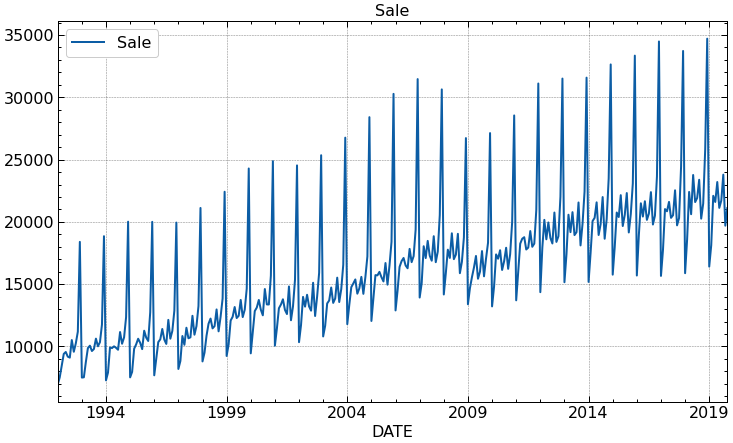

In [55]:
df.plot(figsize=(12, 7), title='Sale');

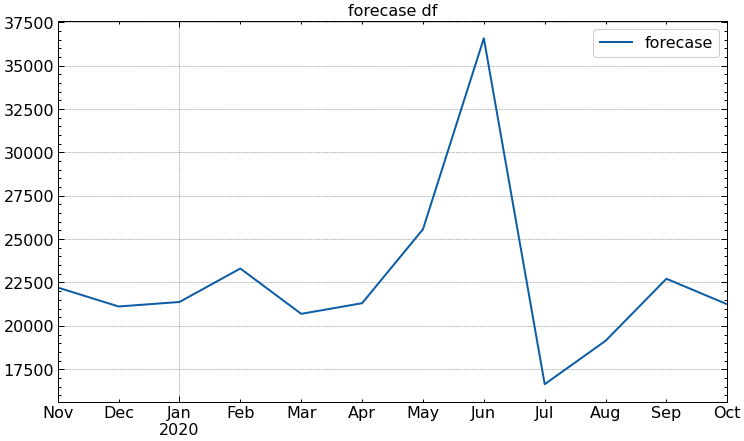

In [56]:
forecase_df.plot(figsize=(12, 7), title='forecase');

## Joint plot

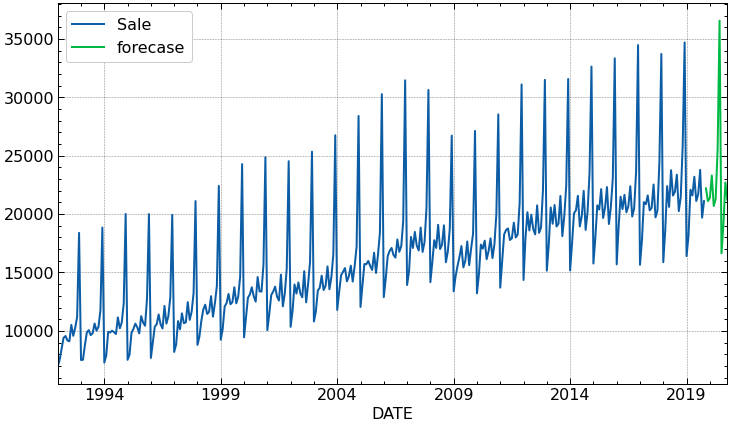

In [57]:
ax = df.plot(figsize=(12,7))
forecase_df.plot(ax=ax);

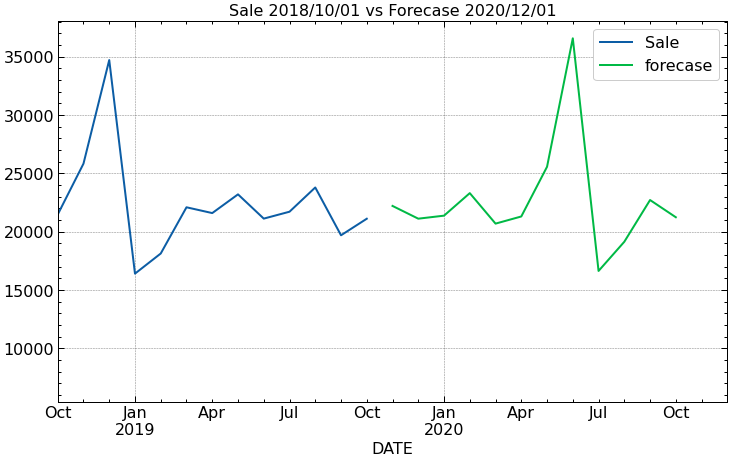

In [58]:
ax = df.plot(figsize=(12,7))
forecase_df.plot(ax=ax);
plt.xlim('2018-10-01', '2020-12-01');
plt.title('Sale 2018/10/01 vs Forecase 2020/12/01');